In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [9]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [10]:
class_names = ['airplane', 'car', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

In [11]:
print("Dataset loaded!")
print(f"Training images: {X_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Image shape: {X_train.shape[1:]} (height, width, RGB channels)")
print()

Dataset loaded!
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)
Image shape: (32, 32, 3) (height, width, RGB channels)



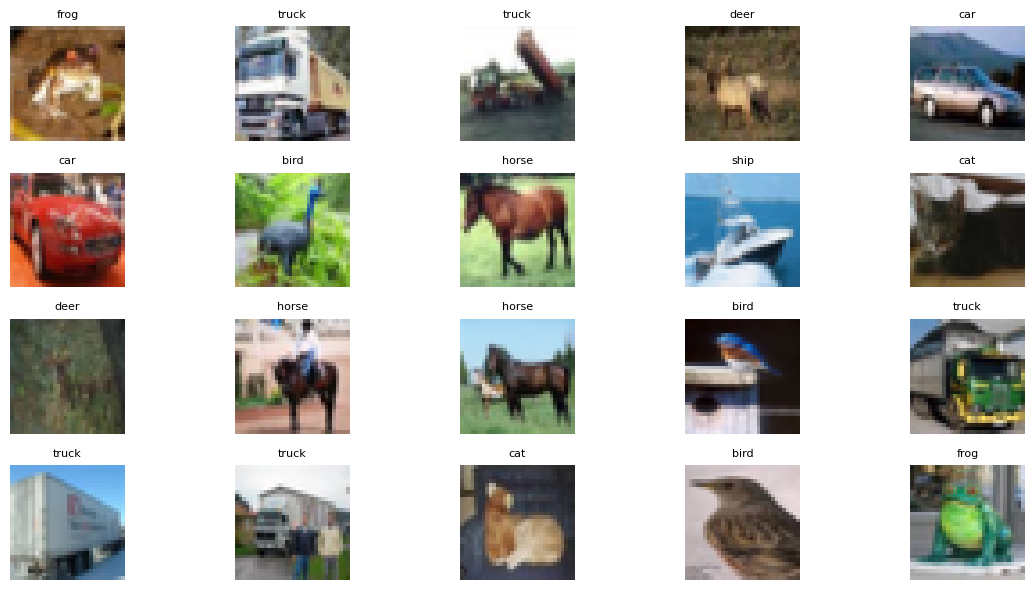

In [12]:
plt.figure(figsize=(12, 6))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
X_train = X_train/255.0
X_test = X_test/255.0

In [14]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [18]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation ='relu', padding='same'),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-11 11:19:13.391874: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1,
    batch_size=64
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.3240 - loss: 1.8253 - val_accuracy: 0.5523 - val_loss: 1.2623
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.5419 - loss: 1.2747 - val_accuracy: 0.5973 - val_loss: 1.1205
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.6109 - loss: 1.1011 - val_accuracy: 0.6572 - val_loss: 0.9612
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.6477 - loss: 1.0034 - val_accuracy: 0.6928 - val_loss: 0.8731
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.6754 - loss: 0.9278 - val_accuracy: 0.6954 - val_loss: 0.8643
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.7018 - loss: 0.8548 - val_accuracy: 0.7241 - val_loss: 0.7871
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.7129 - loss: 0.8217 - val_accuracy: 0.7388 - val_loss: 0.7603
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.7247 - loss: 0.7765 - 

In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Tesst accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7496 - loss: 0.7130
Tesst accuracy: 0.7527999877929688
